# Logistic Regression - Quotation - V1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay)


In [4]:
DATA_PATH = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"

RANDOM_STATE = 42
TEST_FRACTION = 0.20        # last 20% of quotations by date held out as the test set
MIN_CATEGORY_COUNT = 15     # categories seen fewer times than this get grouped into "infrequent"
RARE_WALLTYPE_PCT = 1.0     # wall-type flags present in fewer than this % of rows get grouped

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']

In [5]:
df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
print('Shape:', df_raw.shape)


Shape: (4620, 55)


In [ ]:
info = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing (naive)': df_raw.isna().sum(),
    'pct_missing (naive)': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'n_unique': df_raw.nunique(),
})
info

In [7]:
### ⚠️ Missing values are understated above

SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', ''}

df = df_raw.copy()
# include='string' matters here: pandas 3.x infers a dedicated StringDtype for text columns
# (shows as dtype 'str'), which select_dtypes(include='object') alone will silently miss.
text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

sentinel_hits = {}
for c in text_cols:
    s = df[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    n = int(mask.sum())
    if n > 0:
        sentinel_hits[c] = n
        df.loc[mask, c] = pd.NA

comparison = pd.DataFrame({
    'pct_missing_naive': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'pct_missing_actual': (df.isna().sum() / len(df) * 100).round(1),
})
comparison['difference'] = (comparison['pct_missing_actual'] - comparison['pct_missing_naive']).round(1)
comparison[comparison['difference'] > 0].sort_values('difference', ascending=False)

,pct_missing_naive,pct_missing_actual,difference
Priced_By,0.0,37.8,37.8
Suburb,0.0,37.1,37.1
CLIENT,0.0,0.1,0.1
ADDRESS,0.2,0.3,0.1
number_of_successful,99.6,99.7,0.1
CONTACTS,6.3,6.4,0.1
Successful,74.2,74.3,0.1
Client_Clean,0.0,0.1,0.1


Success
0    3431
1    1189
Name: count, dtype: int64
{0: '74.3%', 1: '25.7%'}


C:\Users\Phong\AppData\Local\Temp\ipykernel_23200\1948496575.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss (0)', 'Won (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])


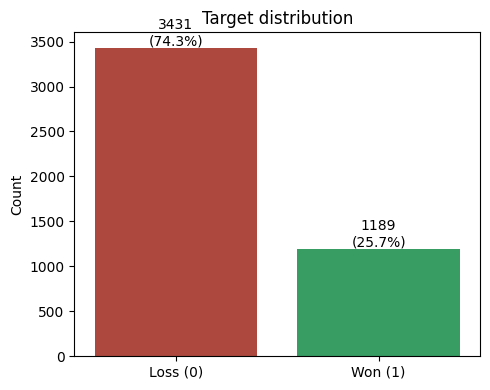

In [9]:
### Target distribution (`Success`)

target_counts = df['Success'].value_counts().sort_index()
target_pct = df['Success'].value_counts(normalize=True).sort_index() * 100
print(target_counts)
print((target_pct.round(1).astype(str) + '%').to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['Loss (0)', 'Won (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])
ax.set_title('Target distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, f'{v}\n({target_pct.values[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

In [46]:
### Checking `Successful` and `number_of_successful` for target leakage
'''
These two column names are suspiciously close to the target `Success`, 
and one is 99.6% missing despite the name implying it should be a count. 
Worth checking before they go anywhere near a model.""")
'''
print('=== Successful: sample non-null values ===')
print(df['Successful'].dropna().unique()[:10])
print()
print('=== Successful populated? vs Success ===')
print(pd.crosstab(df['Successful'].notna(), df['Success'], rownames=['Successful is populated'], colnames=['Success']))

print()
print('=== number_of_successful: sample non-null values ===')
print(df['number_of_successful'].dropna().unique()[:10])
print()
print('=== number_of_successful populated? vs Success ===')
print(pd.crosstab(df['number_of_successful'].notna(), df['Success'], rownames=['number_of_successful is populated'], colnames=['Success']))

LEAKAGE_COLS = ['Successful', 'number_of_successful']
print('Dropping as leakage/unusable:', LEAKAGE_COLS)

print()
print('Duplicate JOB NO values (same job number, different rows):')
dupe_jobs = df[df['JOB NO'].duplicated(keep=False)].sort_values('JOB NO')
print(dupe_jobs[['JOB NO', 'Date', 'CLIENT', 'Value', 'Success']])
print('-> These look like re-quotes under an old job number, not duplicate records (different dates/values). Keeping both rows.')


=== Successful: sample non-null values ===
[1239582 294192 152320 1 766728 224000 32810 520422.08 35581 2544143]

=== Successful populated? vs Success ===
Success                     0     1
Successful is populated            
False                    3431     0
True                        0  1189

=== number_of_successful: sample non-null values ===
['SANTI REQUESTED SUBBIE QUOTE' 'REQUESTED AREAS' 'lost by 20%' 'estimate'
 'HAVE CAGES' 'REQUESTED CAGES' 'REVISED HAVE CAGES'
 'REQUESTED AREAS QUERY PILE LENGHTS' 'REQUESTED AREAS & CAGES '
 'REQUESTED DESIGN']

=== number_of_successful populated? vs Success ===
Success                               0     1
number_of_successful is populated            
False                              3415  1189
True                                 16     0
Dropping as leakage/unusable: ['Successful', 'number_of_successful']

Duplicate JOB NO values (same job number, different rows):
     JOB NO                 Date          CLIENT      Value  Success

count    4.620000e+03
mean     3.308695e+05
std      1.087152e+06
min      0.000000e+00
25%      3.240000e+04
50%      8.974250e+04
75%      2.725565e+05
max      2.930183e+07
Name: Value, dtype: float64

Rows with Value <= 0: 240 (5.2%)


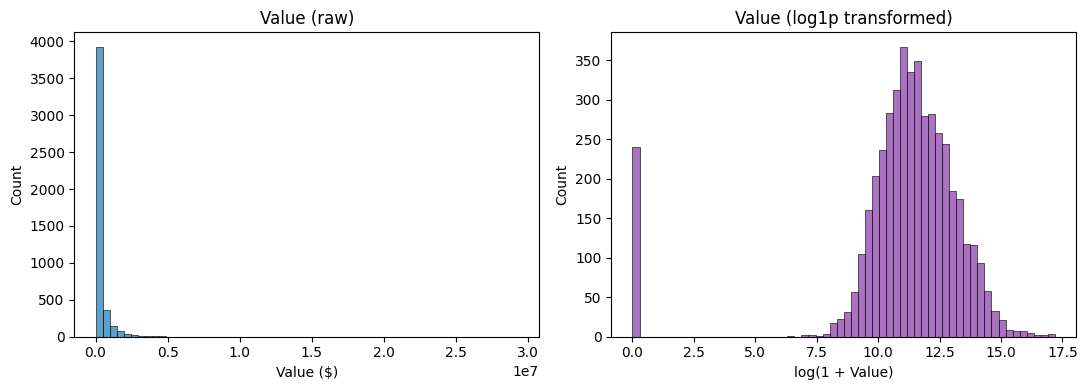

In [47]:
### `Value` distribution
'''`Value` ranges from \\$0 to \\$29.3M and is heavily right-skewed 
(mean \\$331K, median only \\$90K) — typical for project value data, 
but it would dominate a linear model and violate the roughly-linear-in-log-odds 
assumption if used raw. We'll use `log1p(Value)` as the model feature.
**Decision point:** 241 rows (5.2%) have `Value` ≤ 0. 
Their win rate is notably lower (10.4% vs 25.8% overall) and they skew toward 
`Design_and_Build`/`Budget`/`DayWork` project types — 
plausibly legitimate quotes without a fixed price at this stage, 
rather than data errors. **I'm keeping them** (log1p(0)=0 handles zero cleanly) 
rather than dropping ~5% of the data, but flagging this in case you know these 
should be treated differently (e.g. excluded, or a different value should be imputed)
'''
print(df['Value'].describe())
print()
print(f"Rows with Value <= 0: {(df['Value'] <= 0).sum()} ({(df['Value'] <= 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Value'], bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('Value (raw)')
axes[0].set_xlabel('Value ($)')

sns.histplot(np.log1p(df['Value'].clip(lower=0)), bins=60, ax=axes[1], color='#8e44ad')
axes[1].set_title('Value (log1p transformed)')
axes[1].set_xlabel('log(1 + Value)')
plt.tight_layout()
plt.show()

         mean  count
Year                
2013.0  0.311    206
2014.0  0.285    305
2015.0  0.287    275
2016.0  0.323    232
2017.0  0.304    303
2018.0  0.326    227
2019.0  0.298    285
2020.0  0.249    421
2021.0  0.311    396
2022.0  0.274    354
2023.0  0.217    447
2024.0  0.163    412
2025.0  0.188    441
2026.0  0.102    137


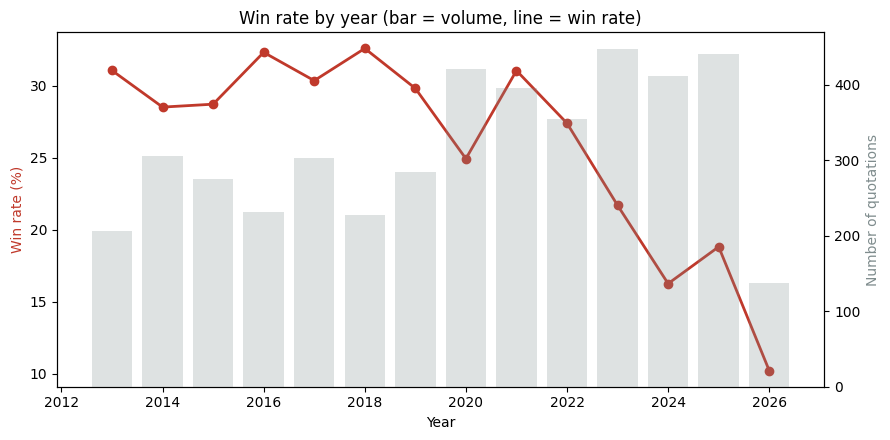

"\nThis is the single most important EDA finding.** Win rate held around \n28 - 33% from 2013 - 2021, then dropped sharply: 21.9% (2023) \n→ 16.2% (2024) → 19.0% (2025) → 10.2% (2026, partial year). \nIt's roughly halved in the last three years relative to the historical average.\n\nThis has two implications:\n1. **A random train/test split would be misleadingly optimistic** — \nit would mix easier historical patterns into the test set. \nWe'll use a time-based split so the evaluation reflects predicting \ngenuinely *future* quotations from *past* ones (confirmed quantitatively in Part 3).\n2. **This is worth a conversation with the business**, \nnot just a modeling footnote — do you know what changed \naround 2022 - 2023 (more competitors, pricing strategy, project mix, \na specific client relationship)? That context could point to features \nwe're missing entirely, and it affects how much to trust older rows as \nrepresentative of current conditions.\n"

In [ ]:
### Win rate over time

df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
yearly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.year)['Success'].agg(['mean', 'count'])
yearly.index.name = 'Year'
print(yearly.round(3))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly.index, yearly['mean']*100, marker='o', color='#c0392b', linewidth=2)
ax1.set_ylabel('Win rate (%)', color='#c0392b')
ax1.set_xlabel('Year')
ax1.set_title('Win rate by year (bar = volume, line = win rate)')

ax2 = ax1.twinx()
ax2.bar(yearly.index, yearly['count'], alpha=0.25, color='#7f8c8d')
ax2.set_ylabel('Number of quotations', color='#7f8c8d')
ax2.grid(False)
plt.tight_layout()
plt.show()

'''
This is the single most important EDA finding.** Win rate held around 
28 - 33% from 2013 - 2021, then dropped sharply: 21.9% (2023) 
→ 16.2% (2024) → 19.0% (2025) → 10.2% (2026, partial year). 
It's roughly halved in the last three years relative to the historical average.

This has two implications:
1. **A random train/test split would be misleadingly optimistic** — 
it would mix easier historical patterns into the test set. 
We'll use a time-based split so the evaluation reflects predicting 
genuinely *future* quotations from *past* ones (confirmed quantitatively in Part 3).
2. **This is worth a conversation with the business**, 
not just a modeling footnote — do you know what changed 
around 2022 - 2023 (more competitors, pricing strategy, project mix, 
a specific client relationship)? That context could point to features 
we're missing entirely, and it affects how much to trust older rows as 
representative of current conditions.
'''


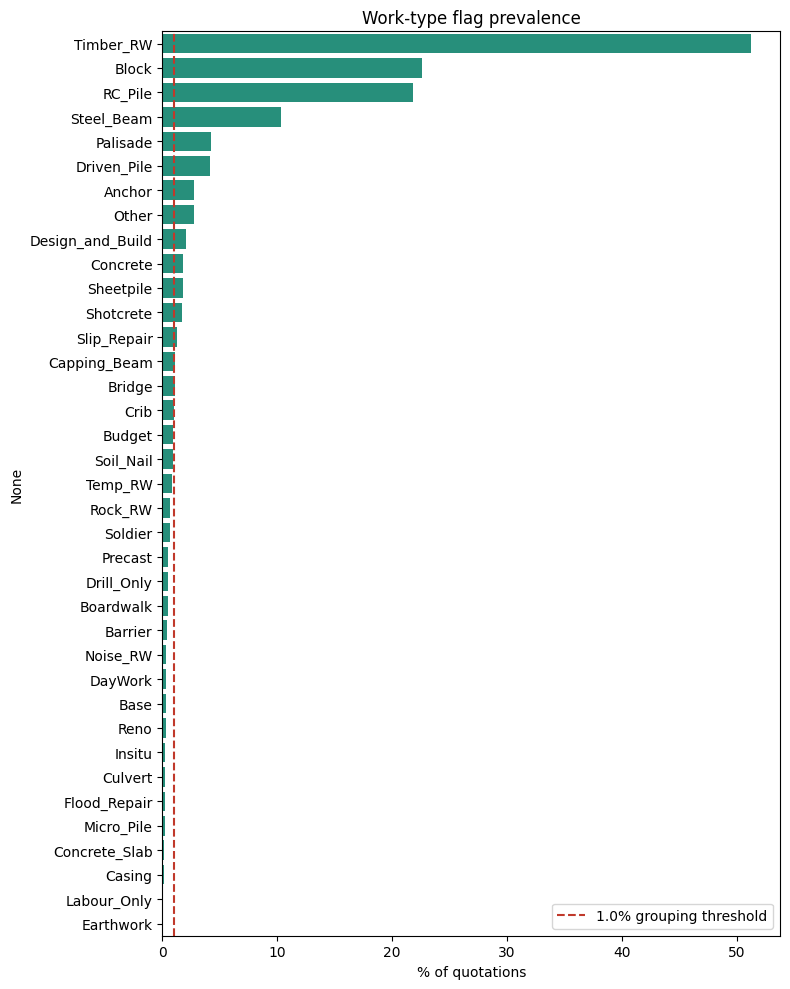

,prevalence_pct,n_rows,success_rate_when_1
Timber_RW,51.212121,2366,0.243
Block,22.640693,1046,0.280
RC_Pile,21.796537,1007,0.231
Steel_Beam,10.346320,478,0.370
Palisade,4.264069,197,0.299
Driven_Pile,4.155844,192,0.135
Anchor,2.748918,127,0.276
Other,2.727273,126,0.278
Design_and_Build,2.012987,93,0.269
Concrete,1.818182,84,0.286


In [8]:
# Cardinality
# =================================================================

cat_cols = ['CLIENT', 'Client_Clean', 'ADDRESS', 'Suburb', 'CONTACTS', 
            'Contact_Clean', 'Priced_By', 'DESCRIPTION']
card = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'pct_missing': (df[cat_cols].isna().sum() / len(df) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card

'''`ADDRESS` (4539 unique) and `CONTACTS`/`Contact_Clean` 
(~2100 - 2900 unique) are essentially free text / near-identifiers — 
not usable as categorical features directly, and each already has a 
cleaner counterpart (`Suburb`, and `Client_Clean` for the client relationship). 
`Client_Clean` (808 unique) and `Suburb` (213 unique) are the two high-cardinality
fields worth keeping, with rare-category grouping (below) to keep them usable 
in a linear model.'''

'''22 of the 37 flags appear in under 1% of rows — several with fewer than 
10 occurrences total (e.g. `Earthwork`: 4 rows, `Micro_Pile`: 9 rows). 
A few even show 0% or 100% success rate purely because the sample is tiny 
(`DayWork`: 16/16 won, `Micro_Pile`: 0/9 won) — real patterns or noise, 
impossible to tell at that sample size. Giving each of these its own coefficient 
in a linear model would fit noise, not signal, so **rare flags (<1% prevalence) 
get grouped into a single `Rare_WorkType` indicator**, keeping the 15 flags with 
enough data to estimate reliably as individual features. Tree-based models later 
can likely handle the raw 37 flags fine — we can revisit this when we get there.'''


# =================================================================
# Wall type flags
# =================================================================
# Wall/work-type binary flags (37 columns)")

prevalence = (df[WALL_TYPE_COLS].mean() * 100).sort_values(ascending=False)
success_rate = pd.Series({c: df.loc[df[c]==1, 'Success'].mean() for c in WALL_TYPE_COLS})
n_when_1 = df[WALL_TYPE_COLS].sum()

flag_summary = pd.DataFrame({'prevalence_pct': prevalence, 'n_rows': n_when_1, 'success_rate_when_1': success_rate.round(3)})
flag_summary = flag_summary.sort_values('prevalence_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=flag_summary['prevalence_pct'], y=flag_summary.index, ax=ax, color='#16a085')
ax.axvline(RARE_WALLTYPE_PCT, color='#c0392b', linestyle='--', label=f'{RARE_WALLTYPE_PCT}% grouping threshold')
ax.set_xlabel('% of quotations')
ax.legend()
ax.set_title('Work-type flag prevalence')
plt.tight_layout()
plt.show()

flag_summary



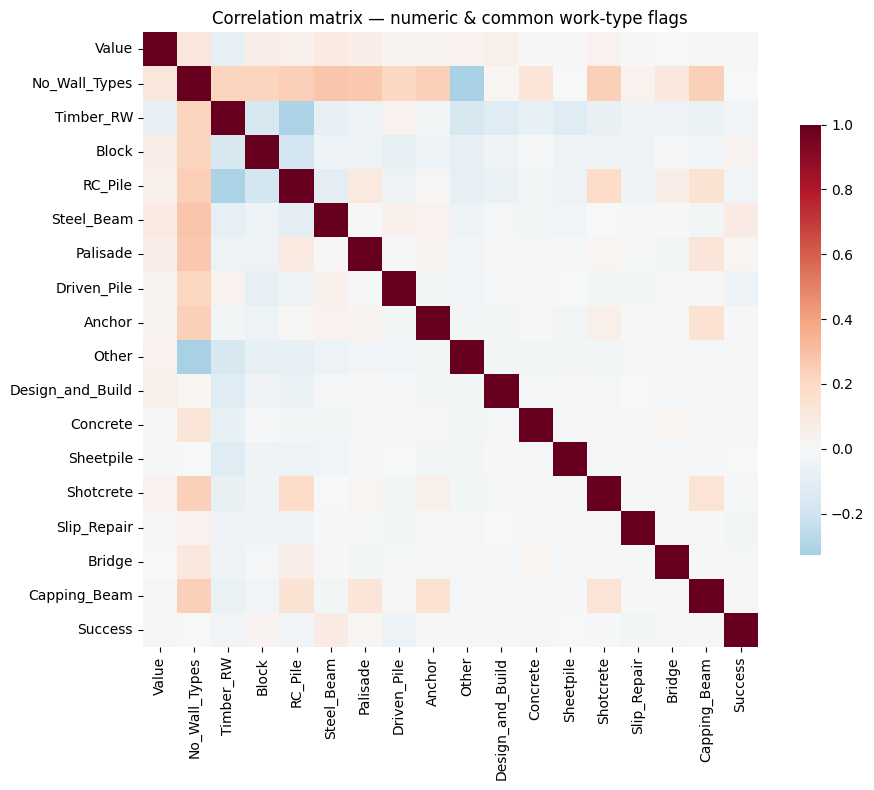

In [24]:
# Correlation
# =================================================================
### Correlation among numeric/binary features")

'''No alarming pairwise correlations among the common flags — 
nothing suggesting we need to drop one of a redundant pair before modeling.'''

corr_cols = ['Value', 'No_Wall_Types'] + list(flag_summary[flag_summary['prevalence_pct']>=1.0].index) + ['Success']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation matrix — numeric & common work-type flags')
plt.tight_layout()
plt.show()



In [22]:
import pandas as pd
from IPython.display import display

# 1. Define the data as a list of lists
data = [
    [
        "'Successful', 'number_of_successful'", 
        "Drop", 
        "Target leakage / unusable free text (see Part 1)"
    ],
    [
        "'JOB NO', 'CLIENT', 'ADDRESS', 'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION'", 
        "Drop from model features", 
        "Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. 'DESCRIPTION' could feed NLP features later — parked, not discarded."
    ],
    [
        "'Date'", 
        "Drop 180 rows (3.9%) where unparseable", 
        "Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute"
    ],
    [
        "'Due_Date', 'Date_Sent'", 
        "Convert to 'Lead_Time_Days' / 'Turnaround_Days' (+ missing-indicator flags)", 
        "Both know at quote time, so no leakage — but given ~65%/~48% missingness, treat these two engineered features as low-confidence and check their importance critically in Part 7"
    ],
    [
        "'Value'", 
        "'log1p' transform", 
        "Heavy right skew (see Part 1)"
    ],
    [
        "37 wall-type flags", 
        "Group 22 rare flags (<1%) into 'Rare_WorkType'", 
        "Avoid fitting noise on flags with <10-40 observations (see Part 1)"
    ],
    [
        "'Client_Clean', 'Suburb', 'Priced_By'", 
        "One-hot with rare categories (<15 occurrences) grouped as 'infrequent'", 
        "Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change"
    ],
    [
        "'Suburb', 'Client_Clean' missing", 
        "Filled as explicit '\"Unknown_*\"' category", 
        "Missingness itself may be informative rather than random"
    ]
]

# 2. Create the DataFrame
df = pd.DataFrame(data, columns=["Column(s)", "Decision", "Why"])

# 3. Display the DataFrame with left-aligned text for better readability 
display(df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))

,Column(s),Decision,Why
0,"'Successful', 'number_of_successful'",Drop,Target leakage / unusable free text (see Part 1)
1,"'JOB NO', 'CLIENT', 'ADDRESS', 'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION'",Drop from model features,"Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. 'DESCRIPTION' could feed NLP features later — parked, not discarded."
2,'Date',Drop 180 rows (3.9%) where unparseable,Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute
3,"'Due_Date', 'Date_Sent'",Convert to 'Lead_Time_Days' / 'Turnaround_Days' (+ missing-indicator flags),"Both know at quote time, so no leakage — but given ~65%/~48% missingness, treat these two engineered features as low-confidence and check their importance critically in Part 7"
4,'Value','log1p' transform,Heavy right skew (see Part 1)
5,37 wall-type flags,Group 22 rare flags (<1%) into 'Rare_WorkType',Avoid fitting noise on flags with <10-40 observations (see Part 1)
6,"'Client_Clean', 'Suburb', 'Priced_By'",One-hot with rare categories (<15 occurrences) grouped as 'infrequent',"Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change"
7,"'Suburb', 'Client_Clean' missing","Filled as explicit '""Unknown_*""' category",Missingness itself may be informative rather than random


In [24]:
# PART 2: CLEANING
# =================================================================
## Part 2 — Cleaning & Feature Engineering
'''
**Decisions made below (flagging the judgment calls — happy to change any of these):**

| Column(s) | Decision | Why |
|---|---|---|
| `Successful`, `number_of_successful` | Drop | Target leakage / unusable free text (see Part 1) |
| `JOB NO`, `CLIENT`, `ADDRESS`, `CONTACTS`, `Contact_Clean`, `Contact_Number_Clean`, `DESCRIPTION` | Drop from model features | Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. `DESCRIPTION` could feed NLP features later — parked, not discarded. |
| `Date` | Drop 180 rows (3.9%) where unparseable | Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute |
| `Due_Date`, `Date_Sent` | Convert to `Lead_Time_Days` / `Turnaround_Days` (+ missing-indicator flags) | Both know at quote time, so no leakage — but given ~65%/~48% missingness, treat these two engineered features as low-confidence and check their importance critically in Part 7 |
| `Value` | `log1p` transform | Heavy right skew (see Part 1) |
| 37 wall-type flags | Group 22 rare flags (<1%) into `Rare_WorkType` | Avoid fitting noise on flags with <10-40 observations (see Part 1) |
| `Client_Clean`, `Suburb`, `Priced_By` | One-hot with rare categories (<15 occurrences) grouped as "infrequent" | Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change |
| `Suburb`, `Client_Clean` missing | Filled as explicit `"Unknown_*"` category | Missingness itself may be informative rather than random | 
'''

df2 = df_raw.copy()

# --- sentinel cleanup (repeated here so Part 2 can run standalone after Part 1) ---
text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    df2.loc[mask, c] = pd.NA

# --- drop leakage + unused raw columns ---
DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION']
df2 = df2.drop(columns=DROP_COLS)

# --- parse dates, drop rows with no valid quote date ---
for c in ['Date', 'Due_Date', 'Date_Sent']:
    df2[c] = pd.to_datetime(df2[c], errors='coerce')
before_n = len(df2)
df2 = df2[df2['Date'].notna()].copy()
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date ({(before_n-len(df2))/before_n*100:.1f}%)')

# --- date-derived features ---
df2['Quote_Year'] = df2['Date'].dt.year
df2['Quote_Month'] = df2['Date'].dt.month

lead = (df2['Due_Date'] - df2['Date']).dt.days
lead = lead.where(lead >= 0)  # negative gap = bad data entry, treat as missing
df2['Lead_Time_Missing'] = lead.isna().astype(int)
df2['Lead_Time_Days'] = lead

turn = (df2['Date_Sent'] - df2['Date']).dt.days
turn = turn.where(turn >= 0)
df2['Turnaround_Missing'] = turn.isna().astype(int)
df2['Turnaround_Days'] = turn

df2 = df2.drop(columns=['Due_Date', 'Date_Sent'])

# --- value transform ---
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))

# --- wall-type flags: collapse rare ---
wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
df2 = df2.drop(columns=rare_walls)

# --- categorical fill ---
df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()

print('Shape after cleaning:', df2.shape)
print(f'Wall-type flags kept individually: {len(common_walls)}  |  collapsed into Rare_WorkType: {len(rare_walls)}')

TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Quote_Month', 'Lead_Time_Days', 'Turnaround_Days']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f'{len(FEATURE_COLS)} raw features going into the pipeline:')
print(f'  Numeric ({len(NUMERIC_FEATURES)}):', NUMERIC_FEATURES)
print(f'  Binary ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}, one-hot encoded below):', CATEGORICAL_FEATURES)



Dropped 179 rows with missing/invalid quote Date (3.9%)
Shape after cleaning: (4441, 31)
Wall-type flags kept individually: 16  |  collapsed into Rare_WorkType: 21
28 raw features going into the pipeline:
  Numeric (6): ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Quote_Month', 'Lead_Time_Days', 'Turnaround_Days']
  Binary (19): ['Timber_RW', 'RC_Pile', 'Steel_Beam', 'Sheetpile', 'Anchor', 'Block', 'Shotcrete', 'Capping_Beam', 'Slip_Repair', 'Bridge', 'Concrete', 'Design_and_Build', 'Driven_Pile', 'Palisade', 'Crib', 'Other', 'Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing']
  Categorical (3, one-hot encoded below): ['Client_Clean', 'Suburb', 'Priced_By']


In [27]:
# PART 3: SPLIT
# =================================================================
'''
Using a time-based split, not a random one.** 
Given the win-rate trend found in Part 1, 
a random split would let the test set "see" the same 
market conditions as training and overstate how well the 
model will do on genuinely future quotations. We sort by 
date and hold out the most recent 20% as the test set — 
this mirrors how the model will actually be used in production 
(predicting quotes you haven't seen the outcome of yet).
The cell after the split quantifies exactly how much this matters.
'''
'''The gap between these two numbers *is* the temporal drift 
from Part 1 showing up in model performance. 
Reporting the random-split number would overstate how the model 
will perform in production by a wide margin. 
Everything from here on uses the time-based split.'''

df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), 'rows |', df_sorted['Date'].iloc[:split_idx].min().date(), '->', df_sorted['Date'].iloc[:split_idx].max().date(), '| win rate:', round(y_train.mean(),3))
print('Test :', len(X_test), 'rows |', df_sorted['Date'].iloc[split_idx:].min().date(), '->', df_sorted['Date'].iloc[split_idx:].max().date(), '| win rate:', round(y_test.mean(),3))

# Why not a random split? (quantifying the difference)

# Same preprocessing + model, evaluated two ways, for comparison only -- 
# not used elsewhere in the notebook.
quick_pre = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')), 
        ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(
        drop='first', 
        handle_unknown='infrequent_if_exist', 
        min_frequency=MIN_CATEGORY_COUNT, 
        sparse_output=False), CATEGORICAL_FEATURES)
])
quick_model = Pipeline([('pre', quick_pre), 
                        ('clf', LogisticRegression(
                          class_weight='balanced', 
                          max_iter=5000, 
                          random_state=RANDOM_STATE))]
                          )

# time-based (what we use everywhere else)
quick_model.fit(X_train, y_train)
auc_time = roc_auc_score(y_test, quick_model.predict_proba(X_test)[:, 1])

# random stratified split (context only)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X, 
    y, 
    test_size=TEST_FRACTION, 
    stratify=y, 
    random_state=RANDOM_STATE)

quick_model.fit(Xr_tr, yr_tr)
auc_random = roc_auc_score(yr_te, quick_model.predict_proba(Xr_te)[:, 1])

print(f'ROC-AUC with time-based split   : {auc_time:.3f}   <- honest, this is what we report')
print(f'ROC-AUC with random split       : {auc_random:.3f}   <- inflated, for illustration only')


Train: 3552 rows | 2013-04-04 -> 2024-03-26 | win rate: 0.279
Test : 889 rows | 2024-03-26 -> 2026-03-31 | win rate: 0.169
ROC-AUC with time-based split   : 0.599   <- honest, this is what we report
ROC-AUC with random split       : 0.777   <- inflated, for illustration only


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [30]:
# PART 4: PREPROCESSING
# =================================================================
## Part 4 — Preprocessing Pipeline
'''
- **Numeric** → median impute (fit on train only, via `Pipeline`) → standardize
- **Binary flags** → passthrough (already 0/1)
- **Categorical** → one-hot, dropping the first level of each 
avoids the dummy-variable trap so coefficients/VIF stay interpretable), 
with categories below `MIN_CATEGORY_COUNT` grouped as "infrequent" — 
and this grouping is fit on the training set only, 
so a rare/unseen client in the test set is correctly treated as unseen, 
not as information leaking backward from the test period.""")
'''
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(
        drop='first', 
        handle_unknown='infrequent_if_exist',
        min_frequency=MIN_CATEGORY_COUNT, 
        sparse_output=False), CATEGORICAL_FEATURES)
])


Fitted. Encoded feature count: 135
=== Test set performance (time-based holdout) ===
Accuracy : 0.822   (naive 'always Loss' baseline: 0.831)
Precision: 0.395
Recall   : 0.100
F1       : 0.160
ROC-AUC  : 0.599
PR-AUC   : 0.261   (baseline = positive rate = 0.169)

              precision    recall  f1-score   support

        Loss       0.84      0.97      0.90       739
         Won       0.39      0.10      0.16       150

    accuracy                           0.82       889
   macro avg       0.62      0.53      0.53       889
weighted avg       0.77      0.82      0.78       889



c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


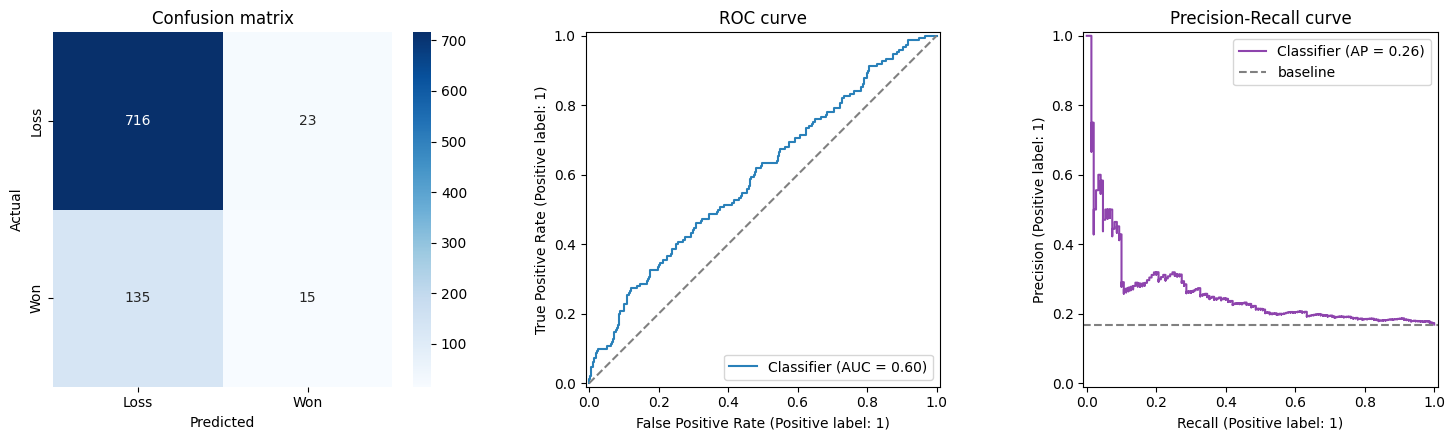

In [33]:
# PART 5: BASELINE MODEL
# =================================================================
## Part 5 — Baseline Logistic Regression")

''' Honest read of this baseline: 
ROC-AUC of ~0.60 is modest — well above random (0.5) but a long way from strong. 
Recall on the "Won" class is low, meaning the model misses most actual wins at 
the default threshold. This is a real, unpolished first pass, not a finished result — 
that's expected for model #1 of 7, and it's exactly why we're comparing against 
tree-based/boosting models next. Two things to keep in mind before concluding 
the model is "bad": (1) the time-based evaluation is intentionally harder than 
a random split, as shown above, and (2) Part 7 shows *why* performance is limited — 
mostly temporal drift, not obviously fixable by tweaking this model alone.'''

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
      class_weight='balanced', 
      max_iter=5000, 
      random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
print('Fitted. Encoded feature count:', len(log_reg.named_steps['preprocessor'].get_feature_names_out()))


y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout) ===')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#2980b9')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#8e44ad')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline')
axes[2].set_title('Precision-Recall curve')
axes[2].legend()

plt.tight_layout()
plt.show()



In [34]:
# PART 6: TUNING
# =================================================================
## Part 6 — Light Hyperparameter Tuning
'''
Tuning the regularization strength `C` via time-series cross-validation 
(`TimeSeriesSplit`, not a regular k-fold — regular CV 
would shuffle time order within the training set and reintroduce 
the same leakage problem discussed in Part 3, just one level down)
'''

'''
Tuning `C` alone doesn't meaningfully close the gap — 
consistent with the drift being a data/feature issue more 
than a regularization issue. Keeping `best_log_reg` as the model we explain in Part 7.
'''

param_grid = {'model__C': [0.01, 0.05, 0.1, 0.3, 1.0, 3.0, 10.0]}
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
  log_reg, 
  param_grid, 
  scoring='average_precision', 
  cv=tscv, 
  n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best C:', grid_search.best_params_['model__C'])
print('Best CV PR-AUC (train folds only):', round(grid_search.best_score_, 3))

cv_results = pd.DataFrame(grid_search.cv_results_)[['param_model__C', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['C', 'mean_PR_AUC', 'std_PR_AUC']
cv_results


best_log_reg = grid_search.best_estimator_
y_pred_best = best_log_reg.predict(X_test)
y_proba_best = best_log_reg.predict_proba(X_test)[:, 1]

print('=== Tuned model vs baseline (C=1.0), on the same test set ===')
print(f"{'Metric':<10} {'Baseline':>10} {'Tuned':>10}")
for name, fn in [('ROC-AUC', roc_auc_score), ('PR-AUC', average_precision_score)]:
    print(f'{name:<10} {fn(y_test, y_proba):>10.3f} {fn(y_test, y_proba_best):>10.3f}')
for name, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{name:<10} {fn(y_test, y_pred):>10.3f} {fn(y_test, y_pred_best):>10.3f}')




Best C: 10.0
Best CV PR-AUC (train folds only): 0.516
=== Tuned model vs baseline (C=1.0), on the same test set ===
Metric       Baseline      Tuned
ROC-AUC         0.599      0.602
PR-AUC          0.261      0.260
Precision       0.395      0.364
Recall          0.100      0.107
F1              0.160      0.165


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


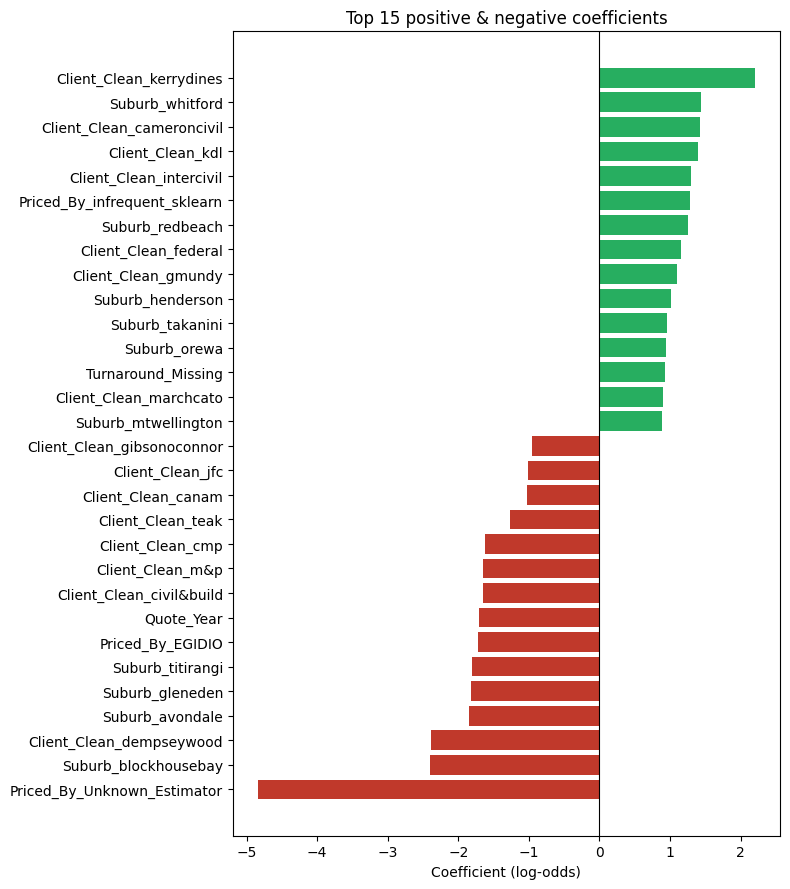

25 / 135 features have a 95% bootstrap CI that excludes zero.


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


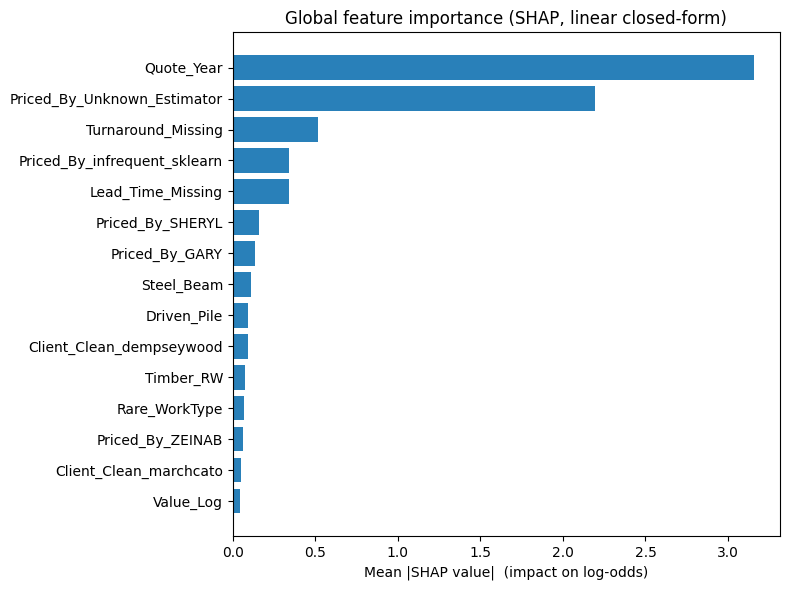

c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


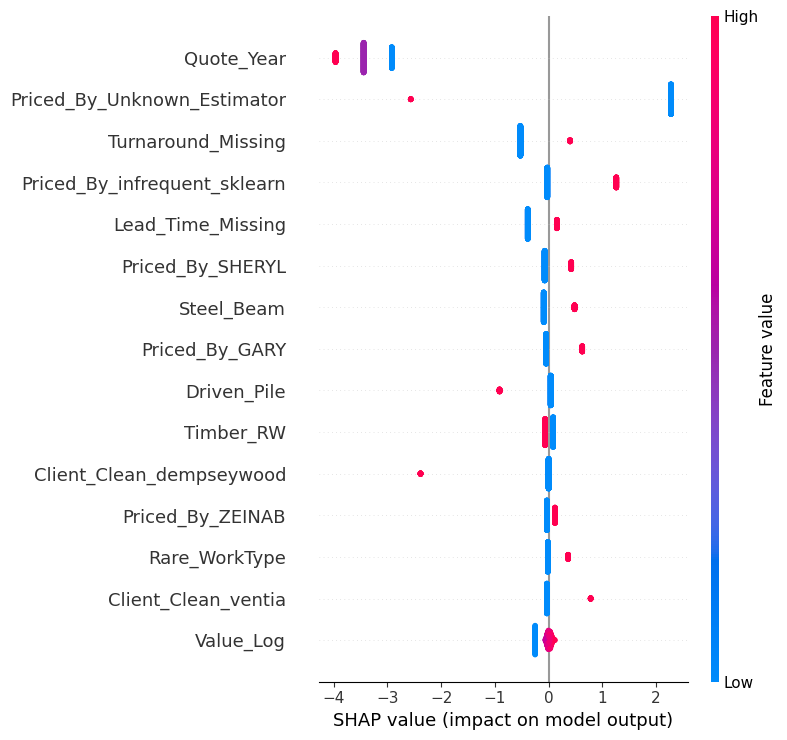

In [ ]:
# PART 7: EXPLAINABILITY
# =================================================================
# Part 7 — Explainability
'''
Three complementary views, from simplest to richest:
1. **Coefficients & odds ratios** — direction and magnitude of each feature's effect
2. **Bootstrap confidence intervals** — which coefficients are reliably different from zero, vs. likely noise
3. **SHAP** — per-prediction attributions, consistent with the workflow we'll reuse for the tree-based models

**A note on statsmodels:** the classical way to get coefficient p-values is `statsmodels.Logit`. 
I've deliberately left it out here — with ~135 one-hot columns 
(many representing small categories even after grouping), 
unregularized MLE is prone to quasi-separation and can fail to 
converge or produce unstable estimates, exactly the instability the 
rare-category grouping in Part 2 was meant to avoid. 
The bootstrap approach below answers the same question ("is this effect real?") 
directly on the regularized model we're actually using, 
so it doesn't fight against the rest of the pipeline. `statsmodels.Logit` 
is still worth trying if you want the classical output — just sanity-check 
convergence warnings if you do.""")
'''
feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]
coefs = best_log_reg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(f'Top {top_n} positive & negative coefficients')
ax.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(15)


"""Reading odds ratios:** an odds ratio of 2.0 means winning odds roughly 
double when that feature is present (or per +1 SD, for scaled numeric features) 
holding everything else fixed; 0.5 means odds roughly halve. Interpret the 
client/suburb-specific ones cautiously — see the bootstrap check below, 
since several are estimated from a fairly small number of quotations."""

# Bootstrap confidence intervals -- resample training ROWS after fixing the encoding,
# so every bootstrap iteration produces the same feature columns and stays comparable.
N_BOOT = 300
X_train_enc = best_log_reg.named_steps['preprocessor'].transform(X_train)
best_C = grid_search.best_params_['model__C']
y_train_arr = y_train.values
n = X_train_enc.shape[0]

rng = np.random.RandomState(RANDOM_STATE)
boot_coefs = np.zeros((N_BOOT, X_train_enc.shape[1]))
for i in range(N_BOOT):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_enc[idx], y_train_arr[idx]
    m = LogisticRegression(C=best_C, class_weight='balanced', max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[i] = m.coef_[0]

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
sig = np.sign(ci_low) == np.sign(ci_high)

boot_df = pd.DataFrame({'feature': clean_names, 'coef_mean': boot_coefs.mean(axis=0),
                         'ci_2.5%': ci_low, 'ci_97.5%': ci_high, 'significant_95pct_CI': sig})
print(f'{sig.sum()} / {len(sig)} features have a 95% bootstrap CI that excludes zero.')
boot_df[boot_df['significant_95pct_CI']].sort_values('coef_mean', ascending=False)


'''Treat features **not** flagged as significant above with real skepticism, 
even if they showed up with a large coefficient in the plot before this — 
that combination is the signature of a category with too few observations to trust.
'''
# Manual closed-form linear SHAP (interventional): phi_i = coef_i * (x_i - mean(x_i)).
# This has no external dependency and is exactly what shap.LinearExplainer computes,
# so it also works as a correctness check on the shap-library plot in the next cell.
X_test_enc = best_log_reg.named_steps['preprocessor'].transform(X_test)
lr_model = best_log_reg.named_steps['model']

mean_train_enc = X_train_enc.mean(axis=0)
base_value = lr_model.intercept_[0] + np.dot(lr_model.coef_[0], mean_train_enc)
shap_manual = (X_test_enc - mean_train_enc) * lr_model.coef_[0]

mean_abs_shap = pd.DataFrame({'feature': clean_names, 'mean_abs_shap': np.abs(shap_manual).mean(axis=0)})
mean_abs_shap = mean_abs_shap.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mean_abs_shap['feature'], mean_abs_shap['mean_abs_shap'], color='#2980b9')
ax.set_xlabel('Mean |SHAP value|  (impact on log-odds)')
ax.set_title('Global feature importance (SHAP, linear closed-form)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


'''
This is the second headline finding, and it reinforces the first:** `Quote_Year` and `Priced_By_Unknown_Estimator` dominate feature importance — well above any individual client, suburb, or work-type effect. Digging into why: `Priced_By` was essentially unpopulated before 2020 and essentially always populated from 2020 onward (a near-perfect step function, not a random gap), so `Priced_By_Unknown_Estimator` is largely standing in for "this is an old record" — overlapping heavily with `Quote_Year` rather than adding independent business signal. In other words: **most of what this model has learned is "win rate has fallen over time,"** not granular client/project drivers. That's a legitimate pattern, but worth deciding deliberately:

- Keep both, accepting the redundancy (harmless for prediction, slightly muddies interpretation)
- Drop `Priced_By` and rely on `Quote_Year`/`Quote_Month` for the temporal trend, keeping the coefficient table focused on business drivers
- Engineer a cleaner "CRM era" flag if you know what actually changed operationally around 2020

Your call — happy to implement whichever once you've had a look.""")
'''
# Standard shap-library workflow (same numbers as the manual computation above; useful because
# we'll reuse this exact pattern for the tree-based models coming next)
import shap

explainer = shap.LinearExplainer(lr_model, X_train_enc, feature_names=clean_names)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)



In [ ]:
# SUMMARY
# =================================================================
## Summary & Open Questions
'''
**What this notebook found, beyond the model itself:**
- `Successful` is target leakage (dropped); `number_of_successful` looks mislabeled 
at the source (dropped, worth a look upstream)
- Several columns hide real missingness behind sentinel text 
(`Suburb` ~38%, `Priced_By` ~38%, `Date_Sent` ~48%, `Due_Date` ~65%) — 
handled, but `Due_Date`/`Date_Sent`-derived features should be trusted 
less given how sparse they are
- **Win rate has roughly halved since 2021 - 2022** — the dominant pattern in 
the data, and worth a conversation with the business about what changed
- A time-based split is materially harder (and more honest) than a random 
split for this data — ROC-AUC drops from ~0.79 to ~0.60
- `Priced_By`'s missingness is essentially a proxy for time period, 
not a real "estimator identity" signal in the recent data

**Questions for you before we lock in the pipeline for the remaining 6 models:**
1. Does the `Successful` = "won contract value" interpretation match the source system?
2. Any idea what changed operationally around 2022 - 2023 that could explain the win-rate drop?
3. Keep, drop, or redesign `Priced_By` given its overlap with `Quote_Year`?
4. Is the ~5% of rows with `Value` ≤ 0 (mostly Design & Build / Budget quotes) 
meant to be treated differently?
5. Happy with grouping thresholds (`MIN_CATEGORY_COUNT=15`, rare wall-types <1%), 
or want them looser/tighter?

**Once we agree on these, the cleaning in Part 2 carries over unchanged to Decision Tree, 
Random Forest, XGBoost, LightGBM, CatBoost and the Neural Network** — 
only the preprocessing specifics (encoding, scaling) and the model itself 
will differ per algorithm.
'''
'''
import joblib
joblib.dump(best_log_reg, 'logistic_regression_pipeline.joblib')
print('Saved fitted pipeline to logistic_regression_pipeline.joblib')
'''


# Logistic Regression - Quotation - V2
Date to Sin - Cos, Multiple Estimator Flag, Calibration and Warterfall Plot 

        mean  count
Month              
1.0    0.248    311
2.0    0.215    358
3.0    0.208    428
4.0    0.246    293
5.0    0.258    383
6.0    0.266    335
7.0    0.242    372
8.0    0.266    455
9.0    0.294    425
10.0   0.292    415
11.0   0.260    415
12.0   0.295    251


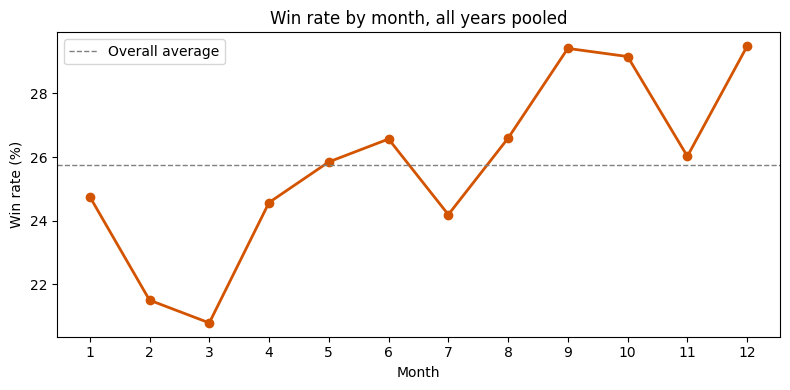

'Win rate dips in Feb–Mar (~21%) and rises through to Sep–Oct–Dec (~29%) — \nroughly an 8-point swing, and importantly a **non-monotonic, wave-shaped** \npattern rather than a steady rise or fall across the year. \nThat shape is exactly what a single linear `Month` feature (1→12) cannot represent: \na linear coefficient can only push predictions consistently up or down as the number \nincreases, never both. This is the real justification for cyclical encoding — not just \n"December should be near January," but "the model needs two degrees of freedom to trace \na curve that goes down, up, down again." Implemented in Part 2 as `Month_Sin`/`Month_Cos`, \nreplacing the raw `Quote_Month` integer.\n\nI checked day-of-month the same way (not plotted here) and found no comparable pattern — \nwin rate by day-of-month is flat within noise (~25–27% regardless of early/mid/late month), \nand there\'s no obvious business mechanism for why the day within a month would affect a \nconstruction bid out

In [51]:
# Seasonality check (motivates cyclical month encoding in Part 2)
# =================================================================
### Seasonality within the year

monthly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.month)['Success'].agg(['mean', 'count'])
monthly.index.name = 'Month'
print(monthly.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly['mean']*100, marker='o', color='#d35400', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Win rate (%)')
ax.set_title('Win rate by month, all years pooled')
ax.axhline(df['Success'].mean()*100, linestyle='--', color='gray', linewidth=1, label='Overall average')
ax.legend()
plt.tight_layout()
plt.show()


"""Win rate dips in Feb–Mar (~21%) and rises through to Sep–Oct–Dec (~29%) — 
roughly an 8-point swing, and importantly a **non-monotonic, wave-shaped** 
pattern rather than a steady rise or fall across the year. 
That shape is exactly what a single linear `Month` feature (1→12) cannot represent: 
a linear coefficient can only push predictions consistently up or down as the number 
increases, never both. This is the real justification for cyclical encoding — not just 
"December should be near January," but "the model needs two degrees of freedom to trace 
a curve that goes down, up, down again." Implemented in Part 2 as `Month_Sin`/`Month_Cos`, 
replacing the raw `Quote_Month` integer.

I checked day-of-month the same way (not plotted here) and found no comparable pattern — 
win rate by day-of-month is flat within noise (~25–27% regardless of early/mid/late month), 
and there's no obvious business mechanism for why the day within a month would affect a 
construction bid outcome. Adding `Day_Sin`/`Day_Cos` on top would mean two more features for 
a linear model already carrying ~135 encoded columns on 3,561 training rows, fit to what looks 
like pure noise. **Recommend skipping it** — happy to add it if you'd rather let the bootstrap 
significance check in Part 7 make that call empirically instead of me pre-judging it."""


In [52]:
# Multi-estimator check (motivates Multi_Estimator flag in Part 2)
# =================================================================
### `Priced_By`: quotations with more than one estimator"

priced_by_known = df[df['Priced_By'].notna()].copy()
priced_by_known['n_estimators'] = priced_by_known['Priced_By'].astype(str).str.split('/').apply(lambda parts: len([p for p in parts if p.strip() != '']))

print(priced_by_known['n_estimators'].value_counts().sort_index())
print()
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Success'].agg(['mean', 'count']))
print()
print('Median Value, single vs multiple estimators:')
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Value'].median())


"""Only ~1.7% of quotations (50 of 2880 with a known estimator) have more than one person credited, 
but it's a meaningfully different group: **46.0% win rate vs 32.3% for single-estimator quotes**, 
and a **4x higher median project value** (\\$423,768 vs \\$105,866). This lines up with what 
you'd expect operationally — bigger, more significant projects get more than one estimator's 
eyes on the price.

Worth building as its own `Multi_Estimator` flag rather than relying on the 
existing one-hot of `Priced_By` combos: at `MIN_CATEGORY_COUNT=15`, almost every 
specific combo (`"GARY / SHERYL"`, `"GARY / ZEINAB"`, ...) falls below the threshold 
and gets grouped into the generic "infrequent" bucket alongside rare *individual* 
estimator names — which conflates two different things ("rarely-seen person" and 
"co-estimated project") and throws away exactly the pattern found above. 
An explicit flag keeps it intact. One caveat: since it's correlated with `Value_Log` 
(already in the model), some of its apparent effect may overlap with "this is just a 
large project" rather than being fully independent — worth watching in the 
coefficient/SHAP results in Part 7 rather than assuming it's a clean standalone driver."""


n_estimators
1    2824
2      49
3       1
Name: count, dtype: int64

                  mean  count
n_estimators                 
False         0.322238   2824
True          0.460000     50

Median Value, single vs multiple estimators:
n_estimators
False    105992.5
True     423768.5
Name: Value, dtype: float64


'Only ~1.7% of quotations (50 of 2880 with a known estimator) have more than one person credited, \nbut it\'s a meaningfully different group: **46.0% win rate vs 32.3% for single-estimator quotes**, \nand a **4x higher median project value** (\\$423,768 vs \\$105,866). This lines up with what \nyou\'d expect operationally — bigger, more significant projects get more than one estimator\'s \neyes on the price.\n\nWorth building as its own `Multi_Estimator` flag rather than relying on the \nexisting one-hot of `Priced_By` combos: at `MIN_CATEGORY_COUNT=15`, almost every \nspecific combo (`"GARY / SHERYL"`, `"GARY / ZEINAB"`, ...) falls below the threshold \nand gets grouped into the generic "infrequent" bucket alongside rare *individual* \nestimator names — which conflates two different things ("rarely-seen person" and \n"co-estimated project") and throws away exactly the pattern found above. \nAn explicit flag keeps it intact. One caveat: since it\'s correlated with `Value_Log` \n(alread

In [55]:
# PART 2: CLEANING
# =================================================================
"""## Part 2 — Cleaning & Feature Engineering

**Decisions made below (flagging the judgment calls — happy to change any of these):**

| Column(s) | Decision | Why |
|---|---|---|
| `Successful`, `number_of_successful` | Drop | Target leakage / unusable free text (see Part 1) |
| `JOB NO`, `CLIENT`, `ADDRESS`, `CONTACTS`, `Contact_Clean`, `Contact_Number_Clean`, `DESCRIPTION` | Drop from model features | Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. `DESCRIPTION` could feed NLP features later — parked, not discarded. |
| `Date` | Drop 180 rows (3.9%) where unparseable | Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute |
| `Due_Date`, `Date_Sent` | Convert to `Lead_Time_Days` / `Turnaround_Days` (+ missing-indicator flags) | Both know at quote time, so no leakage — but given ~65%/~48% missingness, treat these two engineered features as low-confidence and check their importance critically in Part 7 |
| `Value` | `log1p` transform | Heavy right skew (see Part 1) |
| 37 wall-type flags | Group 22 rare flags (<1%) into `Rare_WorkType` | Avoid fitting noise on flags with <10-40 observations (see Part 1) |
| `Client_Clean`, `Suburb`, `Priced_By` | One-hot with rare categories (<15 occurrences) grouped as "infrequent" | Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change |
| `Suburb`, `Client_Clean` missing | Filled as explicit `"Unknown_*"` category | Missingness itself may be informative rather than random |
| `Date` → `Quote_Month` | Cyclical `Month_Sin`/`Month_Cos` instead of a raw 1–12 integer | Win rate by month is wave-shaped, not monotonic — a linear feature can't represent that (see Part 1) |
| `Priced_By` | New `Multi_Estimator` flag (1 if more than one person credited) | Rare combos mostly fall into the "infrequent" bucket otherwise, hiding a real pattern (46% vs 32% win rate — see Part 1) |
"""

df2 = df_raw.copy()

# --- sentinel cleanup (repeated here so Part 2 can run standalone after Part 1) ---
text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    df2.loc[mask, c] = pd.NA

# --- drop leakage + unused raw columns ---
DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION']
df2 = df2.drop(columns=DROP_COLS)

# --- parse dates, drop rows with no valid quote date ---
for c in ['Date', 'Due_Date', 'Date_Sent']:
    df2[c] = pd.to_datetime(df2[c], errors='coerce')
before_n = len(df2)
df2 = df2[df2['Date'].notna()].copy()
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date ({(before_n-len(df2))/before_n*100:.1f}%)')

# --- date-derived features ---
df2['Quote_Year'] = df2['Date'].dt.year

# Cyclical month encoding: a raw 1-12 integer forces a monotonic effect, but win rate by
# month is wave-shaped (dips Feb-Mar, peaks Sep-Dec -- see Part 1). Sin/Cos together let the
# model place each month anywhere on a circle, so Dec and Jan end up close together too.
df2['Month_Sin'] = np.sin(2 * np.pi * df2['Date'].dt.month / 12)
df2['Month_Cos'] = np.cos(2 * np.pi * df2['Date'].dt.month / 12)

lead = (df2['Due_Date'] - df2['Date']).dt.days
lead = lead.where(lead >= 0)  # negative gap = bad data entry, treat as missing
df2['Lead_Time_Missing'] = lead.isna().astype(int)
df2['Lead_Time_Days'] = lead

turn = (df2['Date_Sent'] - df2['Date']).dt.days
turn = turn.where(turn >= 0)
df2['Turnaround_Missing'] = turn.isna().astype(int)
df2['Turnaround_Days'] = turn

df2 = df2.drop(columns=['Due_Date', 'Date_Sent'])

# --- value transform ---
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))

# --- wall-type flags: collapse rare ---
wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
df2 = df2.drop(columns=rare_walls)

# --- multi-estimator flag (computed before Priced_By missing values are filled in below,
#     so an unknown estimator correctly defaults to "not flagged" rather than miscounted) ---
n_estimators = df2['Priced_By'].fillna('').astype(str).str.split('/').apply(
    lambda parts: len([p for p in parts if p.strip() != ''])
)
df2['Multi_Estimator'] = (n_estimators > 1).astype(int)

# --- categorical fill ---
df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()

print('Shape after cleaning:', df2.shape)
print(f"Multi_Estimator flag: {df2['Multi_Estimator'].sum()} quotations ({df2['Multi_Estimator'].mean()*100:.1f}%)")
print(f'Wall-type flags kept individually: {len(common_walls)}  |  collapsed into Rare_WorkType: {len(rare_walls)}')


TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos', 'Lead_Time_Days', 'Turnaround_Days']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing', 'Multi_Estimator']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f'{len(FEATURE_COLS)} raw features going into the pipeline:')
print(f'  Numeric ({len(NUMERIC_FEATURES)}):', NUMERIC_FEATURES)
print(f'  Binary ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}, one-hot encoded below):', CATEGORICAL_FEATURES)


Dropped 179 rows with missing/invalid quote Date (3.9%)
Shape after cleaning: (4441, 36)
Multi_Estimator flag: 50 quotations (1.1%)
Wall-type flags kept individually: 16  |  collapsed into Rare_WorkType: 21
30 raw features going into the pipeline:
  Numeric (7): ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos', 'Lead_Time_Days', 'Turnaround_Days']
  Binary (20): ['Timber_RW', 'RC_Pile', 'Steel_Beam', 'Sheetpile', 'Anchor', 'Block', 'Shotcrete', 'Capping_Beam', 'Slip_Repair', 'Bridge', 'Concrete', 'Design_and_Build', 'Driven_Pile', 'Palisade', 'Crib', 'Other', 'Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing', 'Multi_Estimator']
  Categorical (3, one-hot encoded below): ['Client_Clean', 'Suburb', 'Priced_By']


In [ ]:
# PART 3: SPLIT
# =================================================================
"""## Part 3 — Train/Test Split

**Using a time-based split, not a random one.** Given the win-rate trend found in Part 1, 
a random split would let the test set "see" the same market conditions as training and 
overstate how well the model will do on genuinely future quotations. We sort by date and 
hold out the most recent 20% as the test set — this mirrors how the model will actually be 
used in production (predicting quotes you haven't seen the outcome of yet).
The cell after the split quantifies exactly how much this matters."""

"""The gap between these two numbers *is* the temporal drift from Part 1 showing up in model 
performance. Reporting the random-split number would overstate how the model will 
perform in production by a wide margin. Everything from here on uses the time-based split."""

df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), 'rows |', df_sorted['Date'].iloc[:split_idx].min().date(), '->', df_sorted['Date'].iloc[:split_idx].max().date(), '| win rate:', round(y_train.mean(),3))
print('Test :', len(X_test), 'rows |', df_sorted['Date'].iloc[split_idx:].min().date(), '->', df_sorted['Date'].iloc[split_idx:].max().date(), '| win rate:', round(y_test.mean(),3))


### Why not a random split? (quantifying the difference)

# Same preprocessing + model, evaluated two ways, for comparison only -- not used elsewhere in the notebook.
quick_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])
quick_model = Pipeline([('pre', quick_pre), ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))])

# time-based (what we use everywhere else)
quick_model.fit(X_train, y_train)
auc_time = roc_auc_score(y_test, quick_model.predict_proba(X_test)[:, 1])

# random stratified split (context only)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=TEST_FRACTION, stratify=y, random_state=RANDOM_STATE)
quick_model.fit(Xr_tr, yr_tr)
auc_random = roc_auc_score(yr_te, quick_model.predict_proba(Xr_te)[:, 1])

print(f'ROC-AUC with time-based split   : {auc_time:.3f}   <- honest, this is what we report')
print(f'ROC-AUC with random split       : {auc_random:.3f}   <- inflated, for illustration only')



Train: 3552 rows | 2013-04-04 -> 2024-03-26 | win rate: 0.279
Test : 889 rows | 2024-03-26 -> 2026-03-31 | win rate: 0.169
ROC-AUC with time-based split   : 0.603   <- honest, this is what we report
ROC-AUC with random split       : 0.778   <- inflated, for illustration only


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


'The gap between these two numbers *is* the temporal drift from Part 1 showing up in model \nperformance. Reporting the random-split number would overstate how the model will \nperform in production by a wide margin. Everything from here on uses the time-based split.'

In [59]:
# PART 4: PREPROCESSING
# =================================================================
"""## Part 4 — Preprocessing Pipeline

- **Numeric** → median impute (fit on train only, via `Pipeline`) → standardize
- **Binary flags** → passthrough (already 0/1)
- **Categorical** → one-hot, dropping the first level of each (avoids the dummy-variable 
trap so coefficients/VIF stay interpretable), with categories below `MIN_CATEGORY_COUNT` 
grouped as "infrequent" — and this grouping is fit on the training set only, so a 
rare/unseen client in the test set is correctly treated as unseen, not as information 
leaking backward from the test period."""

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                           min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])

Fitted. Encoded feature count: 137
=== Test set performance (time-based holdout) ===
Accuracy : 0.821   (naive 'always Loss' baseline: 0.831)
Precision: 0.371
Recall   : 0.087
F1       : 0.141
ROC-AUC  : 0.603
PR-AUC   : 0.262   (baseline = positive rate = 0.169)

              precision    recall  f1-score   support

        Loss       0.84      0.97      0.90       739
         Won       0.37      0.09      0.14       150

    accuracy                           0.82       889
   macro avg       0.61      0.53      0.52       889
weighted avg       0.76      0.82      0.77       889



c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


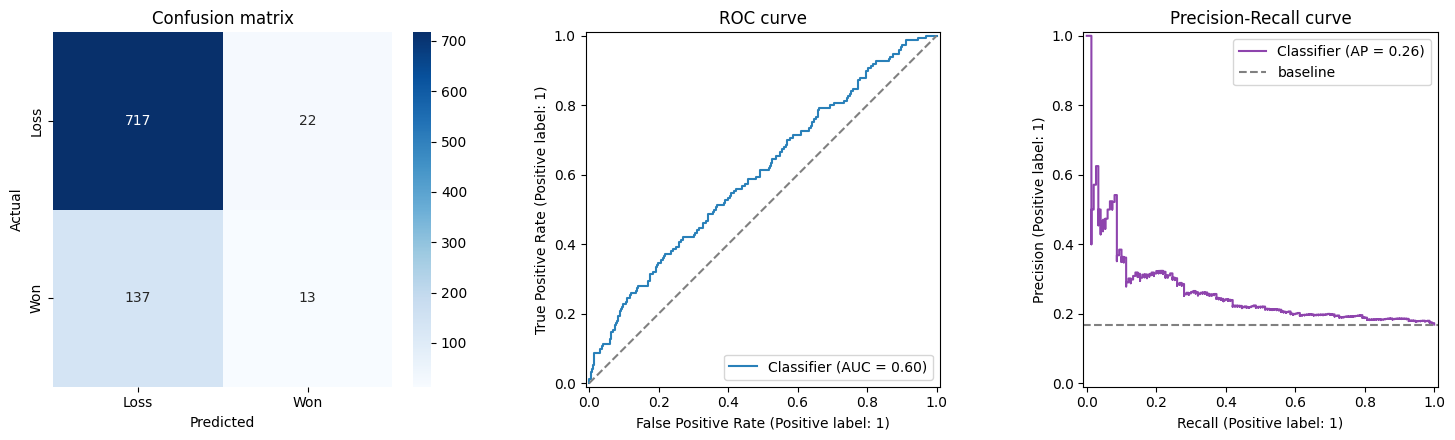

In [61]:
# PART 5: BASELINE MODEL
# =================================================================
## Part 5 — Baseline Logistic Regression")

"""**Honest read of this baseline:** ROC-AUC of ~0.60 is modest — well above random (0.5) 
but a long way from strong. Recall on the "Won" class is low, meaning the model misses 
most actual wins at the default threshold. This is a real, unpolished first pass, not a 
finished result — that's expected for model #1 of 7, and it's exactly why we're comparing 
against tree-based/boosting models next. Two things to keep in mind before concluding the 
model is "bad": (1) the time-based evaluation is intentionally harder than a random split, 
as shown above, and (2) Part 7 shows *why* performance is limited — mostly temporal drift, 
not obviously fixable by tweaking this model alone."""

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
print('Fitted. Encoded feature count:', len(log_reg.named_steps['preprocessor'].get_feature_names_out()))


y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout) ===')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#2980b9')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#8e44ad')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline')
axes[2].set_title('Precision-Recall curve')
axes[2].legend()

plt.tight_layout()
plt.show()



In [ ]:
# PART 6: TUNING
# =================================================================
"""## Part 6 — Hyperparameter Tuning

Searching four things jointly, via time-series cross-validation (`TimeSeriesSplit`, 
not a regular k-fold — regular CV would shuffle time order within the training set and 
reintroduce the same leakage problem discussed in Part 3, just one level down):
- **`C`** — regularization strength
- **`penalty`** — `l1`, `l2`, or `elasticnet`. L1 is worth including specifically because 
it zeros out coefficients rather than just shrinking them — with ~135 one-hot columns 
from the high-cardinality categoricals, an L1 solution that drops the uninformative ones 
to exactly zero gives a *sparser, more directly explainable* model, which matters given the 
project's focus on explainability. `solver='saga'` throughout, since it's the one solver 
that supports all three penalty types on equal footing (`lbfgs`, the default, only 
supports `l2`) — tested for convergence on this data first, no warnings at the settings 
used here. `l1_ratio` (only used when `penalty='elasticnet'`) is fixed at 0.5 rather 
than also tuned, to keep the grid a manageable size.
- **`class_weight`** — `None` vs `'balanced'`. Worth tuning rather than assuming `'balanced'` 
is always right: it mainly shifts the decision *threshold*, so it matters a lot for 
accuracy/F1 at a fixed 0.5 cutoff, but much less for `ROC-AUC`/`PR-AUC`, which score 
ranking quality across all thresholds. Since we're optimizing `average_precision` 
(PR-AUC) here, don't be surprised if `None` wins even though the model is imbalanced — 
that's a real result, not a mistake, and it connects directly to the calibration section 
in Part 7.
- Expanded the grid to search penalty (L1/L2/elasticnet, via solver='saga' — the only 
solver that supports all three """

"""If `class_weight=None` won the search, precision/recall/F1 at the default 0.5 threshold 
may look *worse* than the Part 5 baseline even though ranking quality (ROC-AUC/PR-AUC) 
is as good or better — expected, not a bug: `class_weight='balanced'` was doing threshold work, 
not ranking work. Two honest options from here: keep `class_weight='balanced'` for a model 
whose default `.predict()` output is usable as-is, or keep the tuned choice and pick an 
explicit operating threshold deliberately (Part 7 picks this up again after calibration, 
since threshold selection is more meaningful once the probabilities themselves are trustworthy).

Tuning alone doesn't meaningfully close the gap from Part 3 — consistent with the drift being 
a data/feature issue more than a regularization issue. Keeping `best_log_reg` as the model we 
explain in Part 7."""

param_grid = {
    'model__solver': ['saga'],
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__C': [0.05, 0.1, 1.0, 3.0],
    'model__class_weight': [None, 'balanced'],
    'model__l1_ratio': [0.5],   # only applies when penalty='elasticnet'; ignored otherwise
}
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(log_reg, param_grid, scoring='average_precision', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV PR-AUC (train folds only):', round(grid_search.best_score_, 3))

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_model__penalty', 'param_model__C', 'param_model__class_weight', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['penalty', 'C', 'class_weight', 'mean_PR_AUC', 'std_PR_AUC']
cv_results.sort_values('mean_PR_AUC', ascending=False).head(10)


best_log_reg = grid_search.best_estimator_
y_pred_best = best_log_reg.predict(X_test)
y_proba_best = best_log_reg.predict_proba(X_test)[:, 1]

n_coefs = best_log_reg.named_steps['model'].coef_[0]
print(f"Non-zero coefficients: {(n_coefs != 0).sum()} / {len(n_coefs)}  (penalty={grid_search.best_params_['model__penalty']})")
print()
print('=== Tuned model vs Part 5 baseline (C=1.0, L2, class_weight=balanced), same test set ===')
print(f"{'Metric':<10} {'Baseline':>10} {'Tuned':>10}")
for name, fn in [('ROC-AUC', roc_auc_score), ('PR-AUC', average_precision_score)]:
    print(f'{name:<10} {fn(y_test, y_proba):>10.3f} {fn(y_test, y_proba_best):>10.3f}')
for name, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{name:<10} {fn(y_test, y_pred):>10.3f} {fn(y_test, y_pred_best):>10.3f}')


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Best params: {'model__C': 3.0, 'model__class_weight': None, 'model__l1_ratio': 0.5, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV PR-AUC (train folds only): 0.518
Non-zero coefficients: 121 / 137  (penalty=l1)

=== Tuned model vs Part 5 baseline (C=1.0, L2, class_weight=balanced), same test set ===
Metric       Baseline      Tuned
ROC-AUC         0.603      0.606
PR-AUC          0.262      0.260
Precision       0.371      0.625
Recall          0.087      0.033
F1              0.141      0.063


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


"If `class_weight=None` won the search, precision/recall/F1 at the default 0.5 threshold \nmay look *worse* than the Part 5 baseline even though ranking quality (ROC-AUC/PR-AUC) \nis as good or better — expected, not a bug: `class_weight='balanced'` was doing threshold work, \nnot ranking work. Two honest options from here: keep `class_weight='balanced'` for a model \nwhose default `.predict()` output is usable as-is, or keep the tuned choice and pick an \nexplicit operating threshold deliberately (Part 7 picks this up again after calibration, \nsince threshold selection is more meaningful once the probabilities themselves are trustworthy).\n\nTuning alone doesn't meaningfully close the gap from Part 3 — consistent with the drift being \na data/feature issue more than a regularization issue. Keeping `best_log_reg` as the model we \nexplain in Part 7."

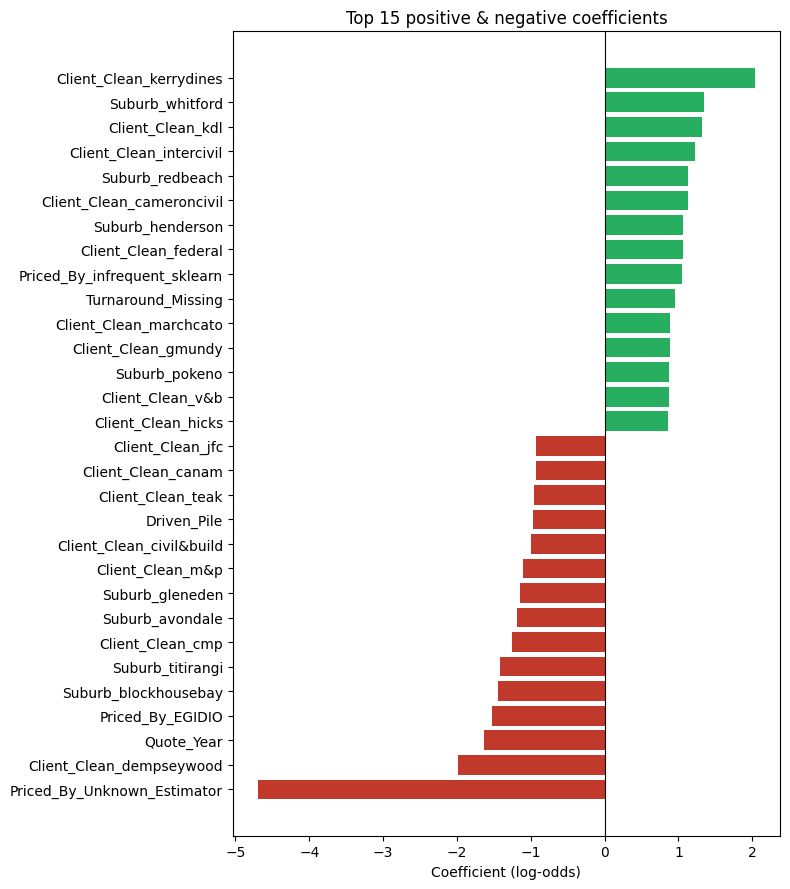

27 / 137 features have a 95% bootstrap CI that excludes zero.


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


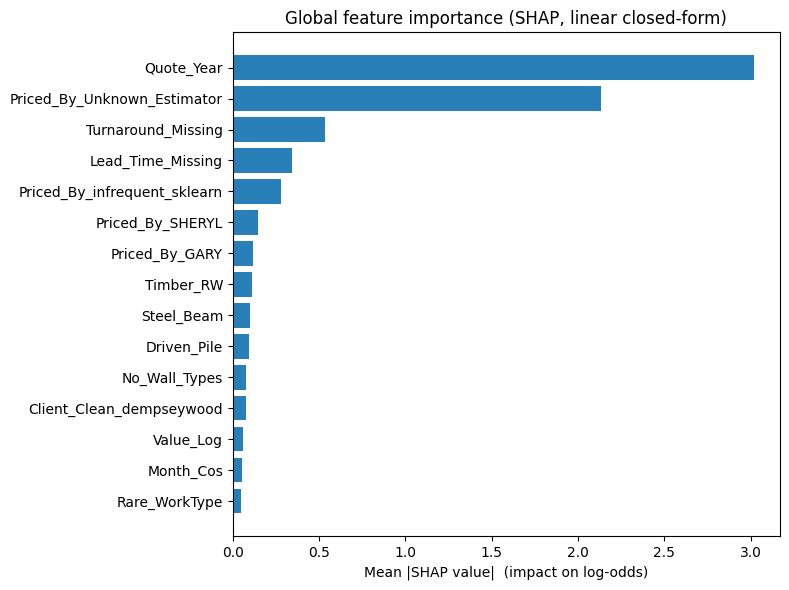

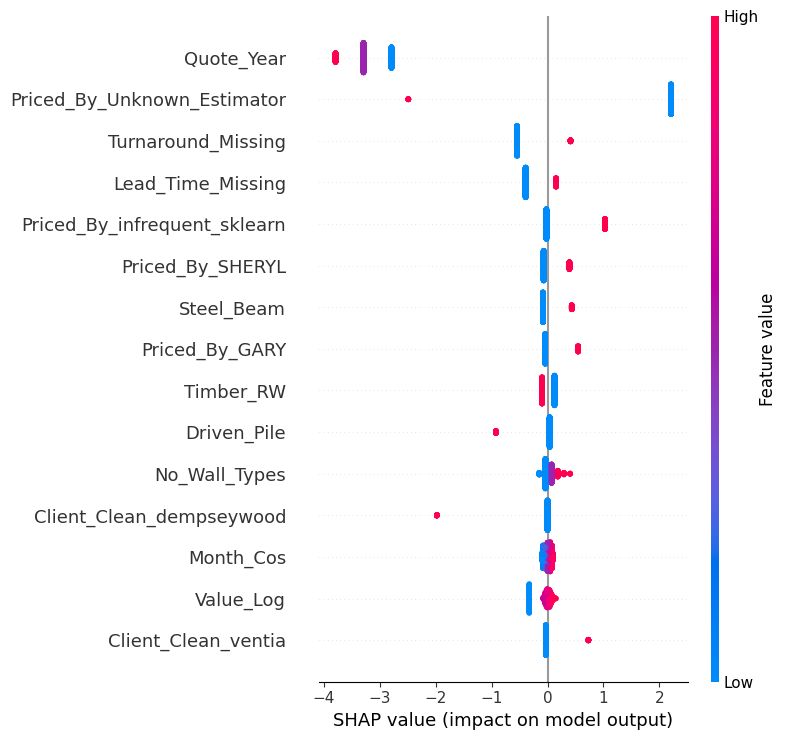

Example: test row 176, actual = Won, predicted probability = 0.769


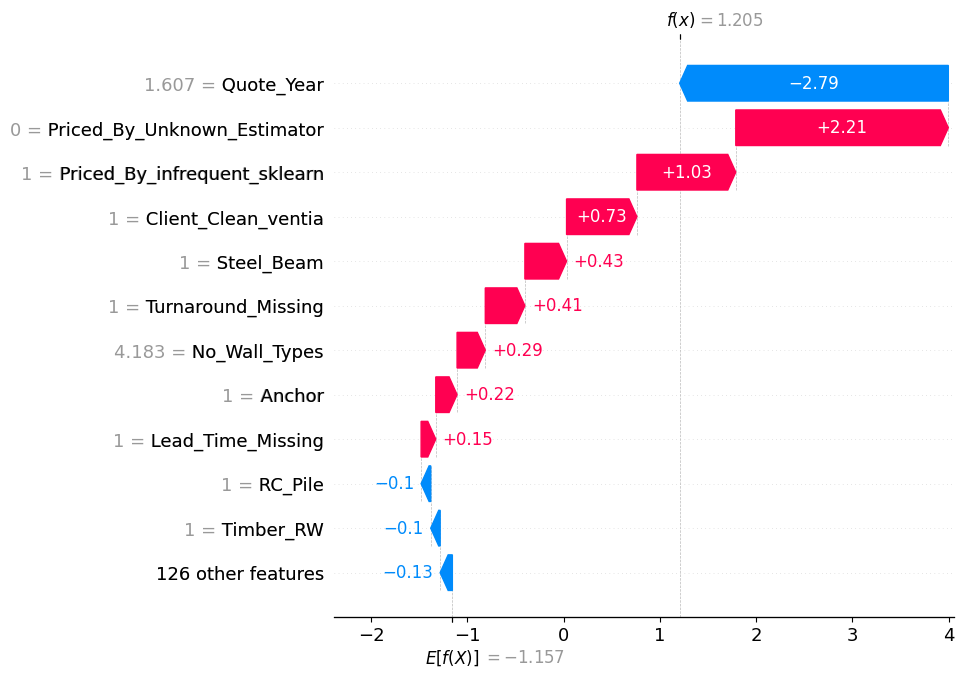

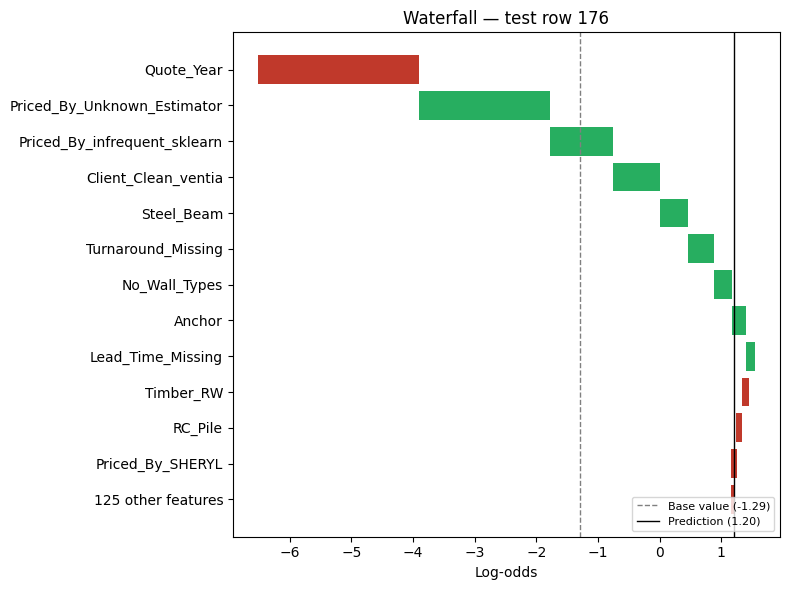

Fit: 2841 | Calibrate: 711 | Test (unchanged): 889


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Brier score, uncalibrated: 0.1536
Brier score, calibrated  : 0.1402   (lower is better)
ROC-AUC, uncalibrated: 0.559
ROC-AUC, calibrated  : 0.559   (should be ~identical -- calibration rescales, it does not re-rank)


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will 

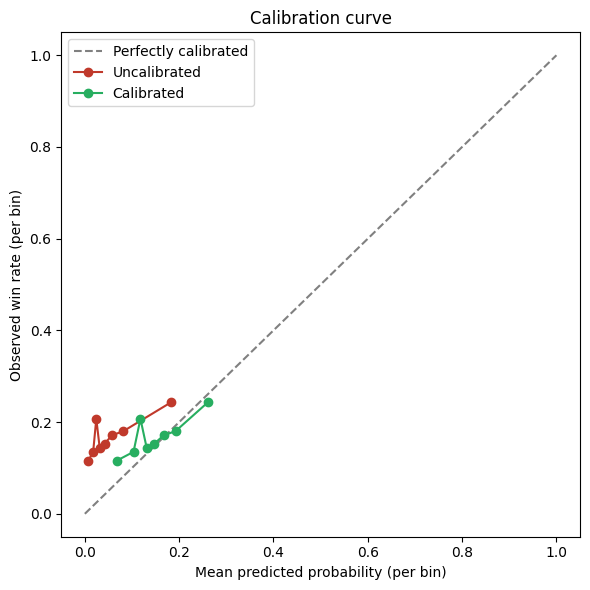

'Points above the diagonal mean the model is under-confident in that range \n(actual win rate higher than predicted); below means over-confident. Whichever \ndirection it comes out for your run, the calibrated curve should track the diagonal \nnoticeably more closely than the raw one — same information the model already had, \njust rescaled to mean what it says.\n**One more decoupling worth doing deliberately:** once probabilities are trustworthy, \nthe *classification* threshold (currently the sklearn default of 0.5) doesn\'t have to be either. \nA threshold chosen for business reasons — "flag any quote above 40% for a follow-up \ncall," "only auto-approve a discount above 60%" — is a separate decision from calibration, \nand arguably the more important one for how this model actually gets used day to day. \nNot implemented here since it depends on costs/benefits only you know, but happy to \nbuild it out (e.g. a threshold that maximizes expected value, or hits a target recall) \nonce

In [63]:
# PART 7: EXPLAINABILITY
# =================================================================
"""## Part 7 — Explainability

Three complementary views, from simplest to richest:
1. **Coefficients & odds ratios** — direction and magnitude of each feature's effect
2. **Bootstrap confidence intervals** — which coefficients are reliably different from zero, 
vs. likely noise
3. **SHAP** — per-prediction attributions, consistent with the workflow we'll reuse for 
the tree-based models
**A note on statsmodels:** the classical way to get coefficient p-values is `statsmodels.Logit`. 
I've deliberately left it out here — with ~135 one-hot columns (many representing small 
categories even after grouping), unregularized MLE is prone to quasi-separation and can fail 
to converge or produce unstable estimates, exactly the instability the rare-category grouping 
in Part 2 was meant to avoid. The bootstrap approach below answers the same question ("is this 
effect real?") directly on the regularized model we're actually using, so it doesn't fight 
against the rest of the pipeline. `statsmodels.Logit` is still worth trying if you want the 
classical output — just sanity-check convergence warnings if you do."""

feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]
coefs = best_log_reg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(f'Top {top_n} positive & negative coefficients')
ax.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(15)


"""**Reading odds ratios:** an odds ratio of 2.0 means winning odds roughly 
double when that feature is present (or per +1 SD, for scaled numeric features) 
holding everything else fixed; 0.5 means odds roughly halve. Interpret the client/suburb-specific 
ones cautiously — see the bootstrap check below, since several are estimated from a 
fairly small number of quotations."""

# Bootstrap confidence intervals -- resample training ROWS after fixing the encoding,
# so every bootstrap iteration produces the same feature columns and stays comparable.
N_BOOT = 300
X_train_enc = best_log_reg.named_steps['preprocessor'].transform(X_train)
best_C = grid_search.best_params_['model__C']
y_train_arr = y_train.values
n = X_train_enc.shape[0]

rng = np.random.RandomState(RANDOM_STATE)
boot_coefs = np.zeros((N_BOOT, X_train_enc.shape[1]))
for i in range(N_BOOT):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_enc[idx], y_train_arr[idx]
    m = LogisticRegression(C=best_C, class_weight='balanced', max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[i] = m.coef_[0]

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
sig = np.sign(ci_low) == np.sign(ci_high)

boot_df = pd.DataFrame({'feature': clean_names, 'coef_mean': boot_coefs.mean(axis=0),
                         'ci_2.5%': ci_low, 'ci_97.5%': ci_high, 'significant_95pct_CI': sig})
print(f'{sig.sum()} / {len(sig)} features have a 95% bootstrap CI that excludes zero.')
boot_df[boot_df['significant_95pct_CI']].sort_values('coef_mean', ascending=False)


"""Treat features **not** flagged as significant above with real skepticism, 
even if they showed up with a large coefficient in the plot before this — that 
combination is the signature of a category with too few observations to trust."""

# Manual closed-form linear SHAP (interventional): phi_i = coef_i * (x_i - mean(x_i)).
# This has no external dependency and is exactly what shap.LinearExplainer computes,
# so it also works as a correctness check on the shap-library plot in the next cell.
X_test_enc = best_log_reg.named_steps['preprocessor'].transform(X_test)
lr_model = best_log_reg.named_steps['model']

mean_train_enc = X_train_enc.mean(axis=0)
base_value = lr_model.intercept_[0] + np.dot(lr_model.coef_[0], mean_train_enc)
shap_manual = (X_test_enc - mean_train_enc) * lr_model.coef_[0]

mean_abs_shap = pd.DataFrame({'feature': clean_names, 'mean_abs_shap': np.abs(shap_manual).mean(axis=0)})
mean_abs_shap = mean_abs_shap.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mean_abs_shap['feature'], mean_abs_shap['mean_abs_shap'], color='#2980b9')
ax.set_xlabel('Mean |SHAP value|  (impact on log-odds)')
ax.set_title('Global feature importance (SHAP, linear closed-form)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


"""**This is the second headline finding, and it reinforces the first:** `Quote_Year` and `Priced_By_Unknown_Estimator` dominate feature importance — well above any individual client, suburb, or work-type effect. Digging into why: `Priced_By` was essentially unpopulated before 2020 and essentially always populated from 2020 onward (a near-perfect step function, not a random gap), so `Priced_By_Unknown_Estimator` is largely standing in for "this is an old record" — overlapping heavily with `Quote_Year` rather than adding independent business signal. In other words: **most of what this model has learned is "win rate has fallen over time,"** not granular client/project drivers. That's a legitimate pattern, but worth deciding deliberately:

- Keep both, accepting the redundancy (harmless for prediction, slightly muddies interpretation)
- Drop `Priced_By` and rely on `Quote_Year`/`Month_Sin`/`Month_Cos` for the temporal trend, keeping the coefficient table focused on business drivers
- Engineer a cleaner "CRM era" flag if you know what actually changed operationally around 2020

Your call — happy to implement whichever once you've had a look."""

# Standard shap-library workflow (same numbers as the manual computation above; useful because
# we'll reuse this exact pattern for the tree-based models coming next).
import shap

explainer = shap.LinearExplainer(lr_model, X_train_enc, feature_names=clean_names)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)

"""### Explaining a single prediction (waterfall)

The summary plot above is *global* — averaged over every test-set prediction. 
A waterfall plot is *local* — it explains one specific quotation, which is what you'd 
actually show someone asking "why does the model think we'll win this one?" Picking the 
quotation the model is most confident about among actual wins in the test set, as a clear 
example (swap `example_idx` for any row you want to inspect instead)."""

# Among actual wins in the test set, find the one the model was most confident about.
test_idx_won = np.where(y_test.values == 1)[0]
example_idx = test_idx_won[np.argmax(y_proba_best[test_idx_won])]
print(f'Example: test row {example_idx}, actual = Won, predicted probability = {y_proba_best[example_idx]:.3f}')

shap.plots.waterfall(shap_values[example_idx], max_display=12)

"""Guaranteed-to-render fallback using the manual SHAP computation from above, 
in case of any `shap`-version rendering quirk in your environment — same numbers, 
plain matplotlib:"""

def manual_waterfall(idx, top_n=12):
    contribs = pd.Series(shap_manual[idx], index=clean_names)
    top = contribs.reindex(contribs.abs().sort_values(ascending=False).index).head(top_n)
    other = contribs.drop(top.index).sum()
    parts = pd.concat([top, pd.Series({f'{len(contribs)-top_n} other features': other})])

    running = base_value
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (name, val) in enumerate(parts.items()):
        color = '#27ae60' if val > 0 else '#c0392b'
        ax.barh(i, val, left=running if val > 0 else running + val, color=color)
        running += val
    ax.set_yticks(range(len(parts)))
    ax.set_yticklabels(parts.index)
    ax.axvline(base_value, color='gray', linestyle='--', linewidth=1, label=f'Base value ({base_value:.2f})')
    ax.axvline(base_value + contribs.sum(), color='black', linestyle='-', linewidth=1, label=f'Prediction ({base_value + contribs.sum():.2f})')
    ax.set_xlabel('Log-odds')
    ax.set_title(f'Waterfall — test row {idx}')
    ax.legend(loc='lower right', fontsize=8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

manual_waterfall(example_idx)


"""## Model Calibration

**Why this matters here specifically:** `predict_proba` on a model tuned with 
`class_weight='balanced'` (or selected via a ranking metric like PR-AUC, as in Part 6) 
is not guaranteed to output *calibrated* probabilities — a predicted 0.35 doesn't 
necessarily mean "35% chance of winning" in the literal, frequency sense. That distinction 
matters a lot for a business use case like `expected_value = P(win) × Value` — 
if the probabilities are systematically off, so is every downstream expected-value 
calculation, even if the model *ranks* quotations correctly

**Method:** fit the tuned pipeline on the first 80% of the training period, 
hold back the last 20% purely to fit a calibration mapping (`CalibratedClassifierCV`, 
Platt/sigmoid scaling — a good fit for logistic regression specifically, and more 
reliable than isotonic on a calibration set this size), then evaluate on the untouched 
final test set. This needs its own held-out slice — reusing the training data the model 
already saw would make the calibration curve look better than it will on genuinely new data, 
the same leakage concern as everywhere else in this notebook. Using `FrozenEstimator` 
(scikit-learn ≥ 1.6) rather than passing `cv=TimeSeriesSplit(...)` directly to 
`CalibratedClassifierCV` is a deliberate choice too — the latter refits several base 
models on different amounts of history and averages them into an ensemble, which changes 
the model being explained above, not just its probability scale. If you're on an older 
scikit-learn without `FrozenEstimator`, `CalibratedClassifierCV(base_estimator=calib_base, 
cv='prefit')` is the equivalent."""

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

# split the training period itself into a fit slice and a calibration slice (chronological, no shuffling)
calib_split = int(split_idx * 0.8)
X_cfit, y_cfit = X.iloc[:calib_split], y.iloc[:calib_split]
X_calib, y_calib = X.iloc[calib_split:split_idx], y.iloc[calib_split:split_idx]
print(f'Fit: {len(X_cfit)} | Calibrate: {len(X_calib)} | Test (unchanged): {len(X_test)}')

calib_base = clone(best_log_reg)          # same tuned hyperparameters, unfitted
calib_base.fit(X_cfit, y_cfit)
proba_uncalibrated = calib_base.predict_proba(X_test)[:, 1]

calibrated_log_reg = CalibratedClassifierCV(FrozenEstimator(calib_base), method='sigmoid')
calibrated_log_reg.fit(X_calib, y_calib)
proba_calibrated = calibrated_log_reg.predict_proba(X_test)[:, 1]

print(f'Brier score, uncalibrated: {brier_score_loss(y_test, proba_uncalibrated):.4f}')
print(f'Brier score, calibrated  : {brier_score_loss(y_test, proba_calibrated):.4f}   (lower is better)')
print(f'ROC-AUC, uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.3f}')
print(f'ROC-AUC, calibrated  : {roc_auc_score(y_test, proba_calibrated):.3f}   (should be ~identical -- calibration rescales, it does not re-rank)')


frac_pos_u, mean_pred_u = calibration_curve(y_test, proba_uncalibrated, n_bins=8, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_calibrated, n_bins=8, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred_u, frac_pos_u, marker='o', color='#c0392b', label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, marker='o', color='#27ae60', label='Calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed win rate (per bin)')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()


"""Points above the diagonal mean the model is under-confident in that range 
(actual win rate higher than predicted); below means over-confident. Whichever 
direction it comes out for your run, the calibrated curve should track the diagonal 
noticeably more closely than the raw one — same information the model already had, 
just rescaled to mean what it says.
**One more decoupling worth doing deliberately:** once probabilities are trustworthy, 
the *classification* threshold (currently the sklearn default of 0.5) doesn't have to be either. 
A threshold chosen for business reasons — "flag any quote above 40% for a follow-up 
call," "only auto-approve a discount above 60%" — is a separate decision from calibration, 
and arguably the more important one for how this model actually gets used day to day. 
Not implemented here since it depends on costs/benefits only you know, but happy to 
build it out (e.g. a threshold that maximizes expected value, or hits a target recall) 
once we're past model selection."""


In [ ]:
# SUMMARY
# =================================================================
"""## Summary & Open Questions

**What this notebook found, beyond the model itself:**
- `Successful` is target leakage (dropped); `number_of_successful` looks mislabeled at the source 
(dropped, worth a look upstream)
- Several columns hide real missingness behind sentinel text (`Suburb` ~38%, `Priced_By` ~38%, 
`Date_Sent` ~48%, `Due_Date` ~65%) — handled, but `Due_Date`/`Date_Sent`-derived 
features should be trusted less given how sparse they are
- **Win rate has roughly halved since 2021–2022**, with a wave-shaped seasonal pattern 
within each year too — the dominant pattern in the data, and worth a conversation with the 
business about what changed
- A time-based split is materially harder (and more honest) than a random split for this data
- `Priced_By`'s missingness is essentially a proxy for time period, not a real "estimator identity"
signal in the recent data — while co-estimation (`Multi_Estimator`) looks like a genuine, 
if partially value-correlated, signal of project significance
- Tuning showed `class_weight` mainly trades off against a fixed 0.5 threshold 
rather than changing ranking quality — worth choosing a business-driven threshold 
deliberately rather than defaulting to 0.5
- Raw `predict_proba` output needed recalibrating before it's safe to use in expected-value 
calculations; `calibrated_log_reg` is the version to reach for if you want probabilities, 
`best_log_reg` for the coefficient/SHAP explanations above

**Questions for you before we lock in the pipeline for the remaining 6 models:**
1. Does the `Successful` = "won contract value" interpretation match the source system?
2. Any idea what changed operationally around 2022–2023 that could explain the win-rate drop?
3. Keep, drop, or redesign `Priced_By` given its overlap with `Quote_Year`?
4. Is the ~5% of rows with `Value` ≤ 0 (mostly Design & Build / Budget quotes) meant to be 
treated differently?
5. Happy with grouping thresholds (`MIN_CATEGORY_COUNT=15`, rare wall-types <1%), or want 
them looser/tighter?
6. Any preference for how the final win/loss threshold should be chosen (target recall, 
target precision, expected-value based) once we're comparing across all 7 models?

**Once we agree on these, the cleaning in Part 2 carries over unchanged to Decision Tree, 
Random Forest, XGBoost, LightGBM, CatBoost and the Neural Network** — only the 
preprocessing specifics (encoding, scaling) and the model itself will differ per algorithm."""

"""import joblib
joblib.dump(best_log_reg, 'logistic_regression_pipeline.joblib')
joblib.dump(calibrated_log_reg, 'logistic_regression_calibrated.joblib')
print('Saved logistic_regression_pipeline.joblib (for coefficients/SHAP) and logistic_regression_calibrated.joblib (for probability/expected-value use)')
"""
